In [1]:
import random 
class Linear:
    def __init__(self):
        self.a=random.uniform(0,1)
        self.b=random.uniform(0,1)
    def predict(self,x):
        return self.a*x+self.b
    def __call__(self,x):
        return self.predict(x)
    def backward(self,x,rez):
        a=self.a
        b=self.b
        self.a -= (2*a*x**2+2*x*b-2*x*rez)*0.05
        self.b -= (2*a*x+2*b-2*rez)*0.05

a=[1,2,3,4,5,2]
b=[7,7,5,8,9,11]
l=Linear()

for k in range(10000):
    loss=0
    for i in range(len(a)-1):
        loss+=(l(a[i])-b[i])**2
        Linear.backward(l,a[i],b[i])
    loss=loss/len(a)
for i in range(len(a)):
    print(l(a[i]))
    
print("loss: ", loss)
print("average loss: ", loss/len(a))

7.519441970911237
6.930246363906194
6.341050756901151
5.751855149896108
5.162659542891065
6.930246363906194
loss:  3.9345315600956305
average loss:  0.6557552600159384


In [2]:
import random

#courtesy of claude, gradient descent
class Linear2:
    def __init__(self):
        self.a = random.uniform(0, 1)
        self.b = random.uniform(0, 1)
        self.lr = 0.01  # learning rate
    
    def predict(self, x):
        return self.a * x + self.b
    
    def __call__(self, x):
        return self.predict(x)
    
    def backward(self, x, y_true, y_pred):
        n = len(x)
        # Calculate gradients
        grad_a = (2/n) * sum((y_pred[i] - y_true[i]) * x[i] for i in range(n))
        grad_b = (2/n) * sum(y_pred[i] - y_true[i] for i in range(n))
        
        # Update parameters
        self.a -= self.lr * grad_a
        self.b -= self.lr * grad_b

x=[1,2,3,4,5,2]
y=[7,7,5,8,9,11]

model = Linear2()

# Training loop
for epoch in range(1000):  # More epochs needed
    y_pred = [model(xi) for xi in x]
    loss = sum((yp - yt) ** 2 for yp, yt in zip(y_pred, y)) / len(x)
    
    # Backward pass
    model.backward(x, y, y_pred)
    
    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.4f}")

# Predictions
for xi, yi in zip(x, y):
    print(f"x={xi}, true={yi}, pred={model(xi):.4f}")

Epoch 0, Loss: 43.7120
Epoch 100, Loss: 7.0443
Epoch 200, Loss: 5.2593
Epoch 300, Loss: 4.3536
Epoch 400, Loss: 3.8940
Epoch 500, Loss: 3.6608
Epoch 600, Loss: 3.5424
Epoch 700, Loss: 3.4824
Epoch 800, Loss: 3.4519
Epoch 900, Loss: 3.4364
x=1, true=7, pred=7.3749
x=2, true=7, pred=7.6056
x=3, true=5, pred=7.8363
x=4, true=8, pred=8.0670
x=5, true=9, pred=8.2977
x=2, true=11, pred=7.6056


In [3]:
#CERINTE LAB 5

In [4]:
#GRAD DE FERICIRE IN FUNCTIE DE FAMILY V1

In [5]:
import pandas as pd
from matplotlib import pyplot as plt

df = pd.read_csv('data/lab05/v1_world-happiness-report-2017.csv',low_memory=False)
fam = df['Family']
happy = df['Happiness.Score']

print(df.head)

<bound method NDFrame.head of                       Country  Happiness.Rank  Happiness.Score  Whisker.high  \
0                      Norway               1            7.537      7.594445   
1                     Denmark               2            7.522      7.581728   
2                     Iceland               3            7.504      7.622030   
3                 Switzerland               4            7.494      7.561772   
4                     Finland               5            7.469      7.527542   
..                        ...             ...              ...           ...   
150                    Rwanda             151            3.471      3.543030   
151                     Syria             152            3.462      3.663669   
152                  Tanzania             153            3.349      3.461430   
153                   Burundi             154            2.905      3.074690   
154  Central African Republic             155            2.693      2.864884   

     Whis

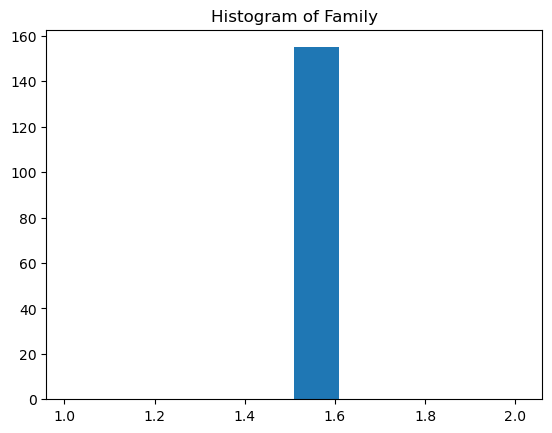

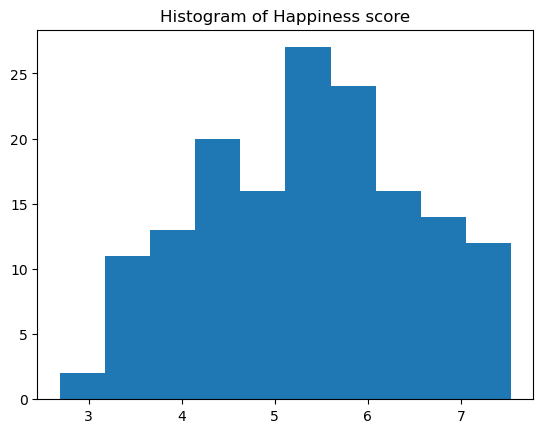

In [6]:
from matplotlib import pyplot as plt


def plotDataHistogram(x, variableName):
    n, bins, patches = plt.hist(x, 10)
    plt.title('Histogram of ' + variableName)
    plt.show()

plotDataHistogram(fam, 'Family')
plotDataHistogram(happy, 'Happiness score')

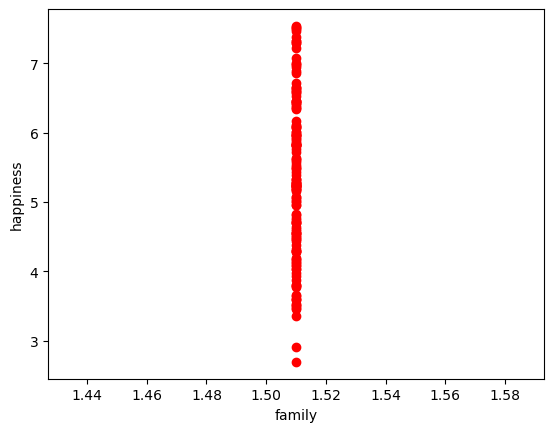

In [7]:
plt.plot(fam, happy, 'ro') 
plt.xlabel('family')
plt.ylabel('happiness')
plt.show()

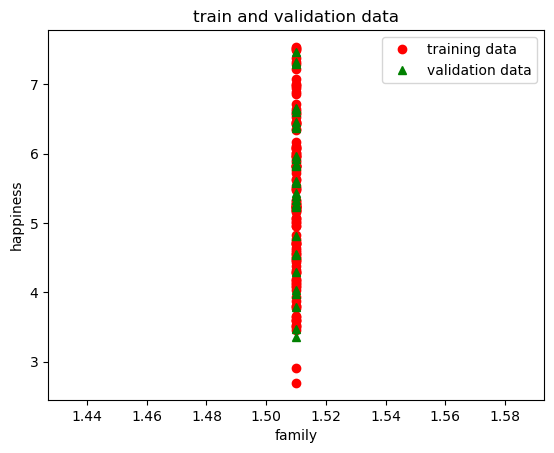

In [8]:
import numpy as np

np.random.seed(47)
indexes = [i for i in range(len(fam))]
trainSample = np.random.choice(indexes, int(0.8 * len(fam)), replace = False)
validationSample = [i for i in indexes  if not i in trainSample]

trainInputs = [fam[i] for i in trainSample]
trainOutputs = [happy[i] for i in trainSample]

validationInputs = [fam[i] for i in validationSample]
validationOutputs = [happy[i] for i in validationSample]

plt.plot(trainInputs, trainOutputs, 'ro', label = 'training data')   #train data are plotted by red and circle sign
plt.plot(validationInputs, validationOutputs, 'g^', label = 'validation data')     #test data are plotted by green and a triangle sign
plt.title('train and validation data')
plt.xlabel('family')
plt.ylabel('happiness')
plt.legend()
plt.show()

In [9]:
#training fara tool 
a = trainInputs
b = trainOutputs
l=Linear()

for k in range(1000):
    loss=0
    for i in range(len(a)-1):
        loss+=(l(a[i])-b[i])**2
        Linear.backward(l,a[i],b[i])
    loss=loss/len(a)
for i in range(len(a)):
    print(l(a[i]), b[i]) #valoare prezisa

print("weights: ")
print(l.a)
print(l.b)

print("metrici: ")
print("suma erori: ", sum([abs(l(a[i]) - b[i]) for i in range(len(a))]))
print("media erori: ", sum([abs(l(a[i]) - b[i]) for i in range(len(a))]) / len(a))

5.194301621537753 5.236999989
5.194301621537753 3.795000076
5.194301621537753 3.494999886
5.194301621537753 7.376999855
5.194301621537753 6.356999874
5.194301621537753 4.119999886
5.194301621537753 5.620999813
5.194301621537753 4.961999893
5.194301621537753 3.644000053
5.194301621537753 4.775000095
5.194301621537753 6.951000214
5.194301621537753 5.822000027
5.194301621537753 7.212999821
5.194301621537753 7.537000179
5.194301621537753 6.343999863
5.194301621537753 5.629000187
5.194301621537753 5.97300005
5.194301621537753 4.513999939
5.194301621537753 7.28399992
5.194301621537753 6.168000221
5.194301621537753 4.465000153
5.194301621537753 7.493999958
5.194301621537753 5.472000122
5.194301621537753 5.011000156
5.194301621537753 4.138999939
5.194301621537753 6.105000019
5.194301621537753 5.293000221
5.194301621537753 7.078999996
5.194301621537753 4.096000195
5.194301621537753 7.521999836
5.194301621537753 5.18200016
5.194301621537753 6.714000225
5.194301621537753 4.714000225
5.19430162153

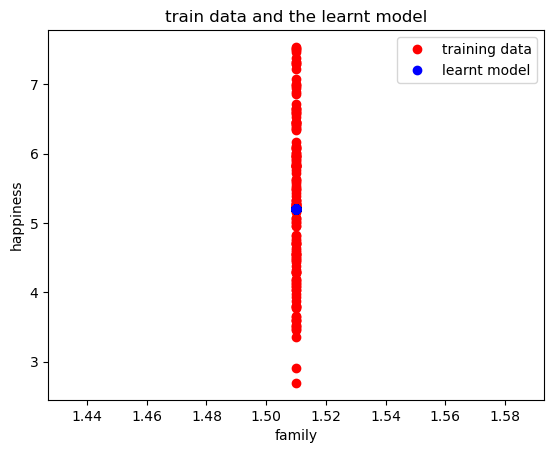

In [10]:
#plot

noOfPoints = 1000
xref = []
val = min(trainInputs)
step = (max(trainInputs) - min(trainInputs)) / noOfPoints
for i in range(1, noOfPoints):
    xref.append(val)
    val += step
yref = [l.b + l.a * el for el in xref] 

trainOutputs = [l(a[i]) for i in range(len(a))]
plt.plot(fam, happy, 'ro', label = 'training data')  #train data are plotted by red and circle sign
plt.plot(xref, yref, 'bo', label = 'learnt model')                  #model is plotted by a blue line
plt.title('train data and the learnt model')
plt.xlabel('family')
plt.ylabel('happiness')
plt.legend()
plt.show()


In [11]:
#testing on validation data
for i in range(len(validationInputs)):
    loss = (Linear.predict(l, validationInputs[i]) - validationOutputs[i])**2
    print(f"input: {validationInputs[i]}, true output: {validationOutputs[i]}, predicted output: {l.predict(validationInputs[i])}, loss: {loss}")

input: 1.510041952, true output: 7.468999863, predicted output: 5.194301621537753, loss: 5.174252089711437
input: 1.510041952, true output: 7.31400013, predicted output: 5.194301621537753, loss: 4.493121766777075
input: 1.510041952, true output: 7.28399992, predicted output: 5.194301621537753, loss: 4.366838978596011
input: 1.510041952, true output: 6.65199995, predicted output: 5.194301621537753, loss: 2.12488441680163
input: 1.510041952, true output: 6.635000229, predicted output: 5.194301621537753, loss: 2.0756124775436575
input: 1.510041952, true output: 6.598999977, predicted output: 5.194301621537753, loss: 1.973177469838341
input: 1.510041952, true output: 6.453999996, predicted output: 5.194301621537753, loss: 1.586839994622828
input: 1.510041952, true output: 6.402999878, predicted output: 5.194301621537753, loss: 1.460951475174876
input: 1.510041952, true output: 6.375, predicted output: 5.194301621537753, loss: 1.3940486609033793
input: 1.510041952, true output: 5.962999821,

In [12]:
#GRAD FERICIRE DUPA FREEDOM + GDP

import pandas as pd
from matplotlib import pyplot as plt

df = pd.read_csv('data/lab05/v1_world-happiness-report-2017.csv',low_memory=False)

freedom = df['Freedom']
gdp = df['Economy..GDP.per.Capita.']
happy = df['Happiness.Score']


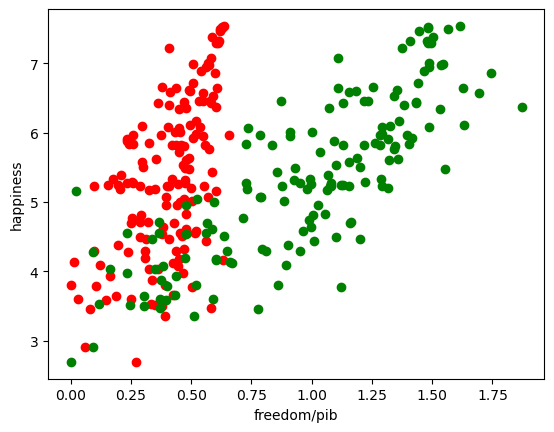

In [13]:
plt.plot(freedom, happy, 'ro')
plt.plot(gdp, happy, 'go')
plt.xlabel('freedom/pib')
plt.ylabel('happiness')
plt.show()


In [14]:
class Linear2feat:
    def __init__(self):
        self.a = random.uniform(0, 1)
        self.b = random.uniform(0, 1)
        self.c = random.uniform(0, 1)
    
    def __call__(self, x, y):
        return self.a * x + self.b * y + self.c
    
    def predict(self, x, y):
        return self(x,y)
    
    def backward(self, x, y, rez):
        # Calculate gradients
        #grad_a = (2/len(x)) * sum((self(x[i], y[i]) - happy[i]) * x[i] for i in range(len(x)))
        #grad_b = (2/len(y)) * sum((self(x[i], y[i]) - happy[i]) * y[i] for i in range(len(y)))
        #grad_c = (2/len(x)) * sum(self(x[i], y[i]) - happy[i] for i in range(len(x)))
        
        error = self.a * x + self.b * y + self.c - rez
        grad_a = 2 * error * x
        grad_b = 2 * error * y
        grad_c = 2 * error
        
        self.a -= 0.01 * grad_a
        self.b -= 0.01 * grad_b
        self.c -= 0.01 * grad_c
        
        

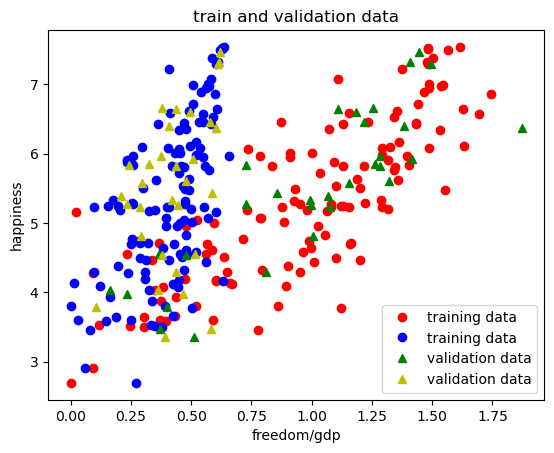

In [15]:
import numpy as np

np.random.seed(47)
indexes = [i for i in range(len(happy))]
trainSample = np.random.choice(indexes, int(0.8 * len(happy)), replace=False)
validationSample = [i for i in indexes if not i in trainSample]

trainInputsGdp = [gdp[i] for i in trainSample]
trainInputsFreedom = [freedom[i] for i in trainSample]

trainOutputs = [happy[i] for i in trainSample]

validationInputsGdp = [gdp[i] for i in validationSample]
validationInputsFreedom = [freedom[i] for i in validationSample]

validationOutputs = [happy[i] for i in validationSample]

plt.plot(trainInputsGdp, trainOutputs, 'ro', label='training data')  
plt.plot(trainInputsFreedom, trainOutputs, 'bo', label='training data')
plt.plot(validationInputsGdp, validationOutputs, 'g^',
         label='validation data')  #test data are plotted by green and a triangle sign
plt.plot(validationInputsFreedom, validationOutputs, 'y^',
         label='validation data') 
plt.title('train and validation data')
plt.xlabel('freedom/gdp')
plt.ylabel('happiness')
plt.legend()
plt.show()

In [16]:
def normalize(data):
    mn, mx = min(data), max(data)
    return [(x - mn) / (mx - mn) for x in data]

trainInputsGdp = normalize(trainInputsGdp)
trainInputsFreedom = normalize(trainInputsFreedom)

In [17]:
#training fara tool
l = Linear2feat()

for i in range(1000):
    loss = 0
    for x, y, z in zip(trainInputsGdp, trainInputsFreedom, trainOutputs):
        loss += (l(x,y) - z)**2
        l.backward(x, y, z)
    
    avg_loss = loss / len(trainOutputs)
    if i % 100 == 0:
        print(avg_loss)
        
print("weights: ")
print(l.a)
print(l.b)
print(l.c)


3.0961319872049278
0.3212859728570426
0.32128581201895773
0.3212858119962358
0.3212858119962314
0.3212858119962314
0.3212858119962314
0.3212858119962314
0.3212858119962314
0.3212858119962314
weights: 
3.0982686487618922
1.7222932062700347
2.5300513942764904


In [18]:
#testing on validation data
for i in range(len(validationInputsGdp)):
    loss = (l(validationInputsGdp[i], validationInputsFreedom[i]) - validationOutputs[i])**2
    print(f"input: ({validationInputsGdp[i]}, {validationInputsFreedom[i]}), true output: {validationOutputs[i]}, predicted output: {l(validationInputsGdp[i], validationInputsFreedom[i])}, loss: {loss}")
    

input: (1.443571925, 0.617950857), true output: 7.468999863, predicted output: 8.06691759455669, loss: 0.3575056137098987
input: (1.405706048, 0.61406213), true output: 7.31400013, predicted output: 7.942901406896578, loss: 0.3955168160821458
input: (1.494387269, 0.612924099), true output: 7.28399992, predicted output: 8.215699630594976, loss: 0.8680643507227617
input: (1.25278461, 0.376895279), true output: 6.65199995, predicted output: 7.060638853587834, loss: 0.16698575352546688
input: (1.10735321, 0.437453747), true output: 6.635000229, predicted output: 6.714352744440806, loss: 0.006296821706783304
input: (1.185295463, 0.494519204), true output: 6.598999977, predicted output: 7.054122232228368, loss: 0.20713626720415537
input: (1.217559695, 0.579392254), true output: 6.453999996, predicted output: 7.300261768120764, loss: 0.7161589869529758
input: (1.384397864, 0.40878123), true output: 6.402999878, predicted output: 7.52332902900033, loss: 1.2551374065811192
input: (1.870765686, 

In [19]:
from sklearn import linear_model

#training cu tool pt v1 happiness score in functie de family

xx = [[el] for el in trainInputs]
regressor = linear_model.LinearRegression()
# regressor = linear_model.SGDRegressor(max_iter =  10000)
regressor.fit(xx, trainOutputs)
w0, w1 = regressor.intercept_, regressor.coef_

print("weights: ")
print(w0)
print(w1)


weights: 
3.8431340350867385
[0.97660383]


In [20]:
#testing pe validation data
for i in range(len(validationInputs)):
    pred = w0 + w1 * validationInputs[i]
    loss = (pred - validationOutputs[i])**2
    print(f"input: {validationInputs[i]}, true output: {validationOutputs[i]}, predicted output: {pred}, loss: {loss}")
    

input: 1.510041952, true output: 7.468999863, predicted output: [5.31784679], loss: [4.62745955]
input: 1.510041952, true output: 7.31400013, predicted output: [5.31784679], loss: [3.98462816]
input: 1.510041952, true output: 7.28399992, predicted output: [5.31784679], loss: [3.86575814]
input: 1.510041952, true output: 6.65199995, predicted output: [5.31784679], loss: [1.77996466]
input: 1.510041952, true output: 6.635000229, predicted output: [5.31784679], loss: [1.73489319]
input: 1.510041952, true output: 6.598999977, predicted output: [5.31784679], loss: [1.64135349]
input: 1.510041952, true output: 6.453999996, predicted output: [5.31784679], loss: [1.29084411]
input: 1.510041952, true output: 6.402999878, predicted output: [5.31784679], loss: [1.17755723]
input: 1.510041952, true output: 6.375, predicted output: [5.31784679], loss: [1.11757291]
input: 1.510041952, true output: 5.962999821, predicted output: [5.31784679], loss: [0.41622244]
input: 1.510041952, true output: 5.9200

In [23]:
#training cu tool pt v1 happiness score in functie de freedom si gdp

xx = [[feat1, feat2] for feat1, feat2 in zip(trainInputsGdp, trainInputsFreedom)]
regressor = linear_model.LinearRegression()
regressor.fit(xx, trainOutputs)
w0, w1, w2 = regressor.intercept_, regressor.coef_[0], regressor.coef_[1]
print("weights: ")
print(w0)
print(w1)
print(w2)


weights: 
2.4835709096039085
3.1551939549565806
1.7145961542481594


In [24]:
#testing pe validation data

for i in range(len(validationInputsGdp)):
    pred = w0 + w1 * validationInputsGdp[i] + w2 * validationInputsFreedom[i]
    loss = (pred - validationOutputs[i])**2
    print(f"input: ({validationInputsGdp[i]}, {validationInputsFreedom[i]}), true output: {validationOutputs[i]}, predicted output: {pred}, loss: {loss}")
    

input: (1.443571925, 0.617950857), true output: 7.468999863, predicted output: 8.097856483835496, loss: 0.3954606495686396
input: (1.405706048, 0.61406213), true output: 7.31400013, predicted output: 7.971714701266848, loss: 0.43258845725673306
input: (1.494387269, 0.612924099), true output: 7.28399992, predicted output: 8.2495698901082, loss: 0.9323253671747492
input: (1.25278461, 0.376895279), true output: 6.65199995, predicted output: 7.082572533866234, loss: 0.18539274997724453
input: (1.10735321, 0.437453747), true output: 6.635000229, predicted output: 6.72754157606532, loss: 0.008563900916664056
input: (1.185295463, 0.494519204), true output: 6.598999977, predicted output: 7.071308714679231, loss: 0.2230755436881482
input: (1.217559695, 0.579392254), true output: 6.453999996, predicted output: 7.3186316295762595, loss: 0.7475878617807505
input: (1.384397864, 0.40878123), true output: 6.402999878, predicted output: 7.552509406238344, loss: 1.3213721555107398
input: (1.870765686, 